In [269]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [270]:
df = pd.read_csv('./Dataset/diabetes.csv')

df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## EDA

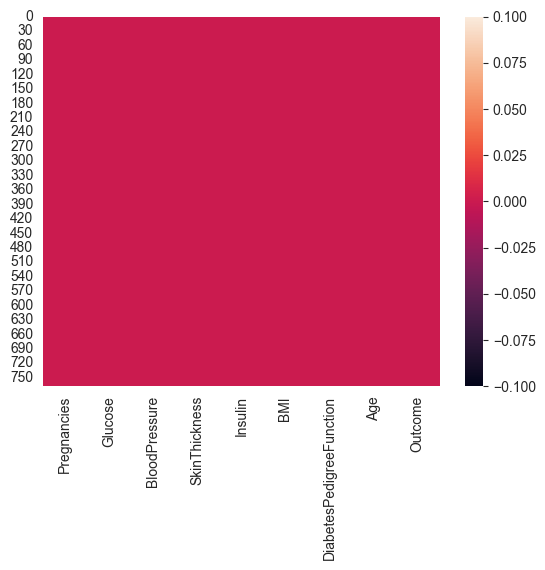

In [271]:
sns.heatmap(df.isna()) # No nan vals

sns.set_style("whitegrid")

<Axes: xlabel='Outcome', ylabel='count'>

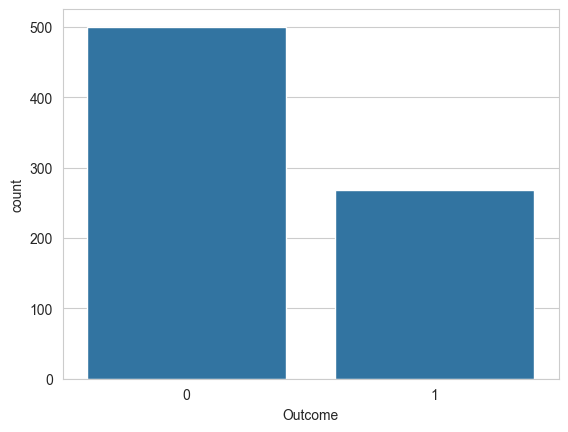

In [272]:
sns.barplot(df['Outcome'].value_counts()) # 0's higher than 1

<Axes: >

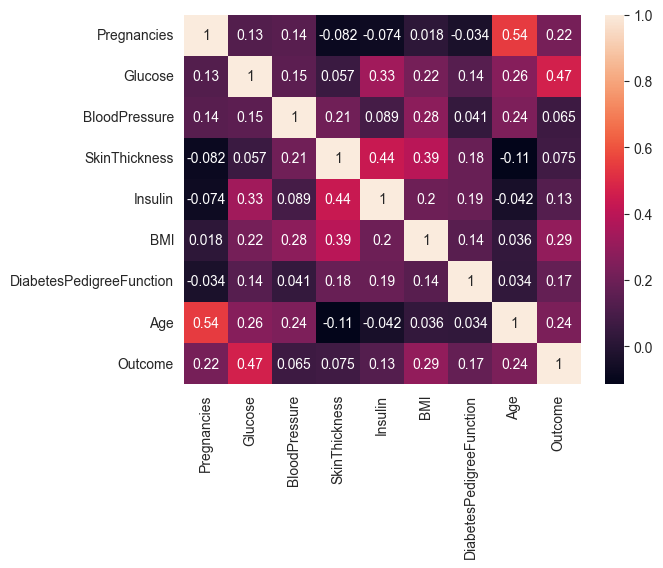

In [273]:
sns.heatmap(df.corr() ,annot=True) #Mostly non linear

In [274]:
# sns.pairplot(df, hue='Outcome', palette='colorblind') #MxN scatters

<Axes: xlabel='Glucose', ylabel='BMI'>

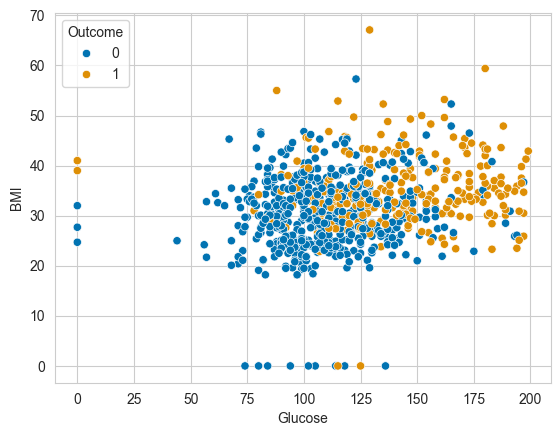

In [275]:
sns.scatterplot(df,x='Glucose',y='BMI', hue='Outcome', palette='colorblind') #As BMI and Glucose increase, chance of diabetes increases

<Axes: xlabel='DiabetesPedigreeFunction', ylabel='Outcome'>

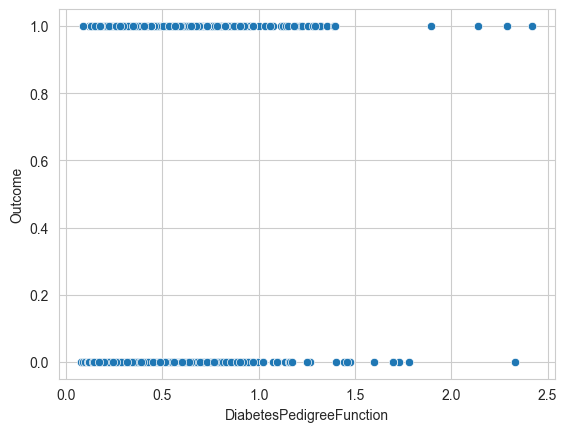

In [276]:
# DiabetesPedigreeFunction: It's a numeric value that summarizes the likelihood of diabetes based on family history (genetics).
sns.scatterplot(df,x='DiabetesPedigreeFunction', y='Outcome')

#No clear correlation can be seen

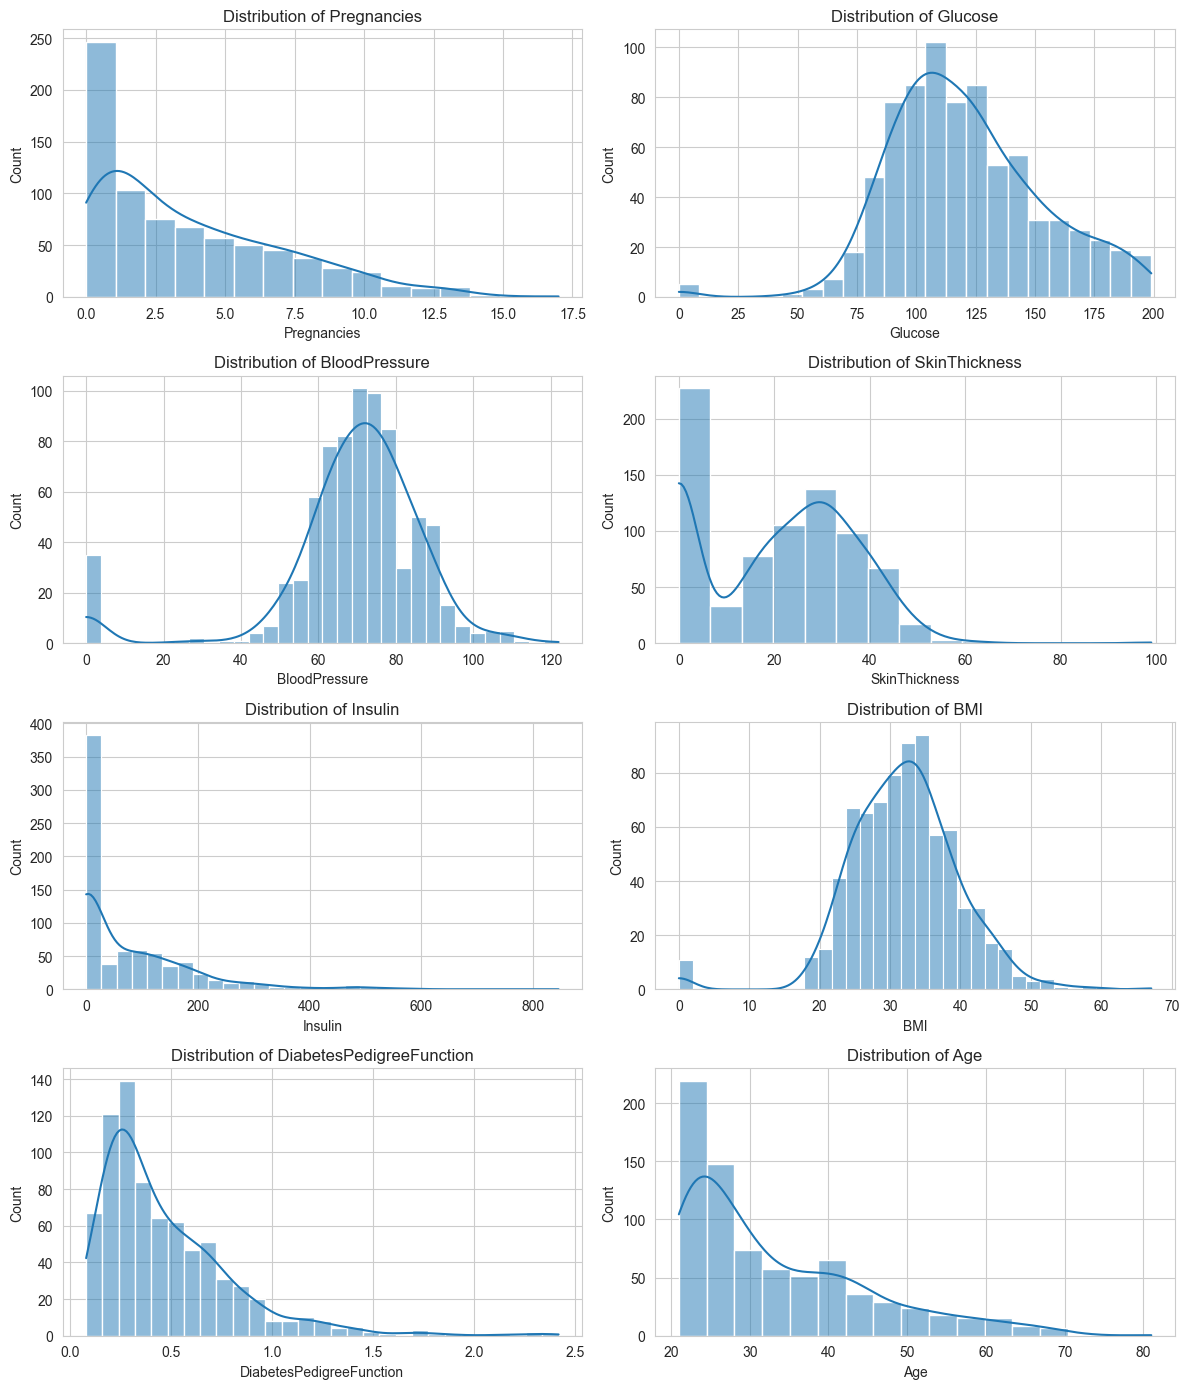

In [277]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(4, 2, figsize=(12, 14))  # 4 rows, 2 columns

sns.histplot(data=df, x='Pregnancies', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Pregnancies')

sns.histplot(data=df, x='Glucose', kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Glucose')

sns.histplot(data=df, x='BloodPressure', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of BloodPressure')

sns.histplot(data=df, x='SkinThickness', kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of SkinThickness')

sns.histplot(data=df, x='Insulin', kde=True, ax=axes[2, 0])
axes[2, 0].set_title('Distribution of Insulin')

sns.histplot(data=df, x='BMI', kde=True, ax=axes[2, 1])
axes[2, 1].set_title('Distribution of BMI')

sns.histplot(data=df, x='DiabetesPedigreeFunction', kde=True, ax=axes[3, 0])
axes[3, 0].set_title('Distribution of DiabetesPedigreeFunction')

sns.histplot(data=df, x='Age', kde=True, ax=axes[3, 1])
axes[3, 1].set_title('Distribution of Age')

plt.tight_layout()
plt.show()


In [278]:
df1 = df.copy()

## Removing Outliers

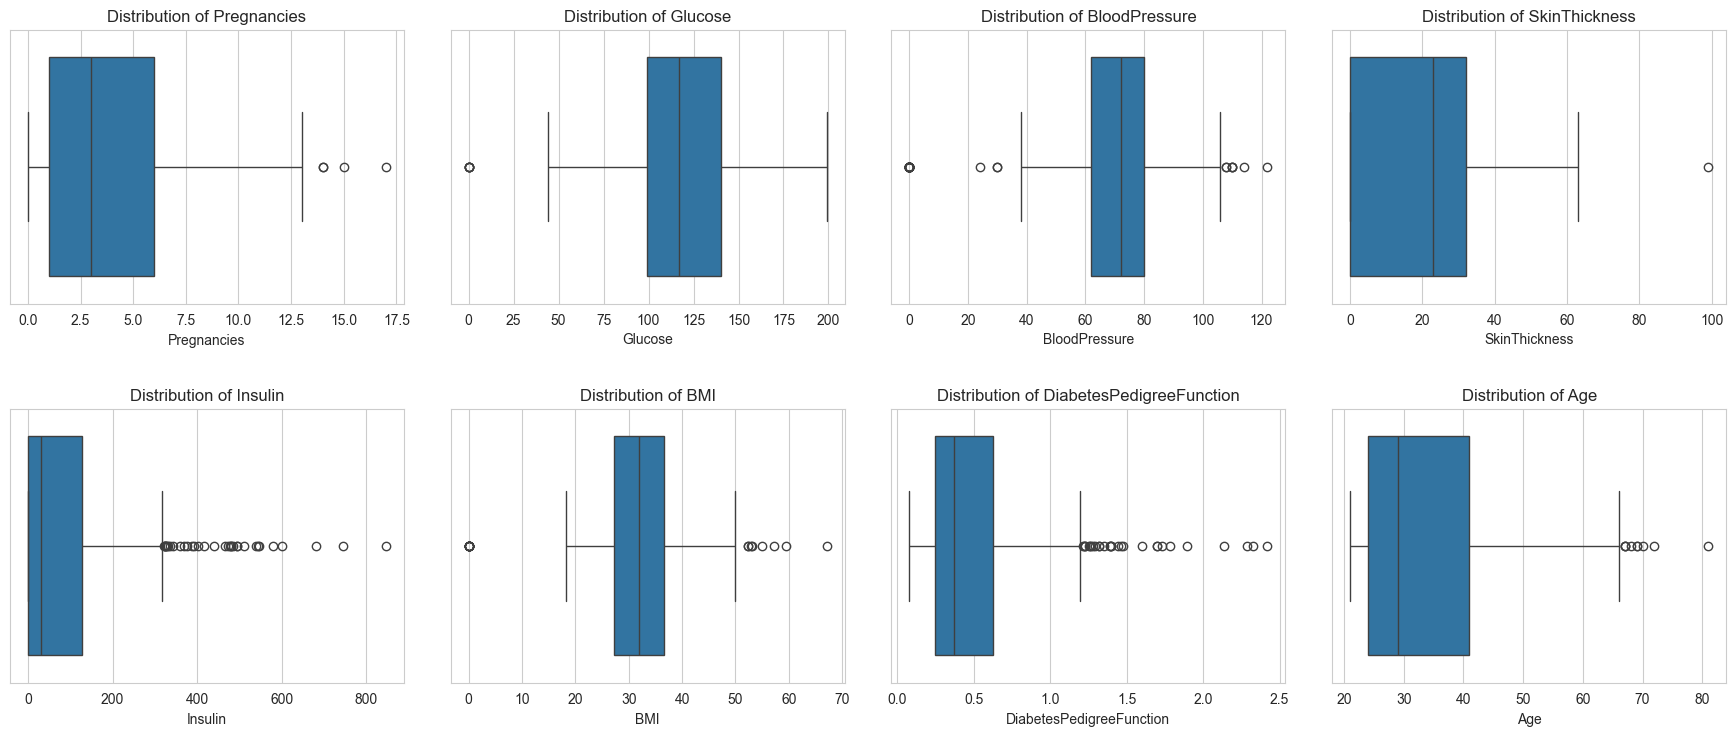

In [279]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create rainbow palette with 8 colors
rainbow_palette = sns.color_palette("rainbow", 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))  # 2 rows, 4 columns

sns.boxplot(data=df, x='Pregnancies', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Pregnancies')

sns.boxplot(data=df, x='Glucose', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Glucose')

sns.boxplot(data=df, x='BloodPressure', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of BloodPressure')

sns.boxplot(data=df, x='SkinThickness', ax=axes[0, 3])
axes[0, 3].set_title('Distribution of SkinThickness')

sns.boxplot(data=df, x='Insulin', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Insulin')

sns.boxplot(data=df, x='BMI', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of BMI')

sns.boxplot(data=df, x='DiabetesPedigreeFunction', ax=axes[1, 2])
axes[1, 2].set_title('Distribution of DiabetesPedigreeFunction')

sns.boxplot(data=df, x='Age', ax=axes[1, 3])
axes[1, 3].set_title('Distribution of Age')

# Improve spacing
plt.tight_layout(pad=3)  # Add padding
plt.show()


In [280]:
# Copy your DataFrame to preserve the original
df_clean = df.copy()

# List of numeric columns (you can choose specific ones if needed)
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= lower_limit) & (df_clean[col] <= upper_limit)]


df = df_clean    


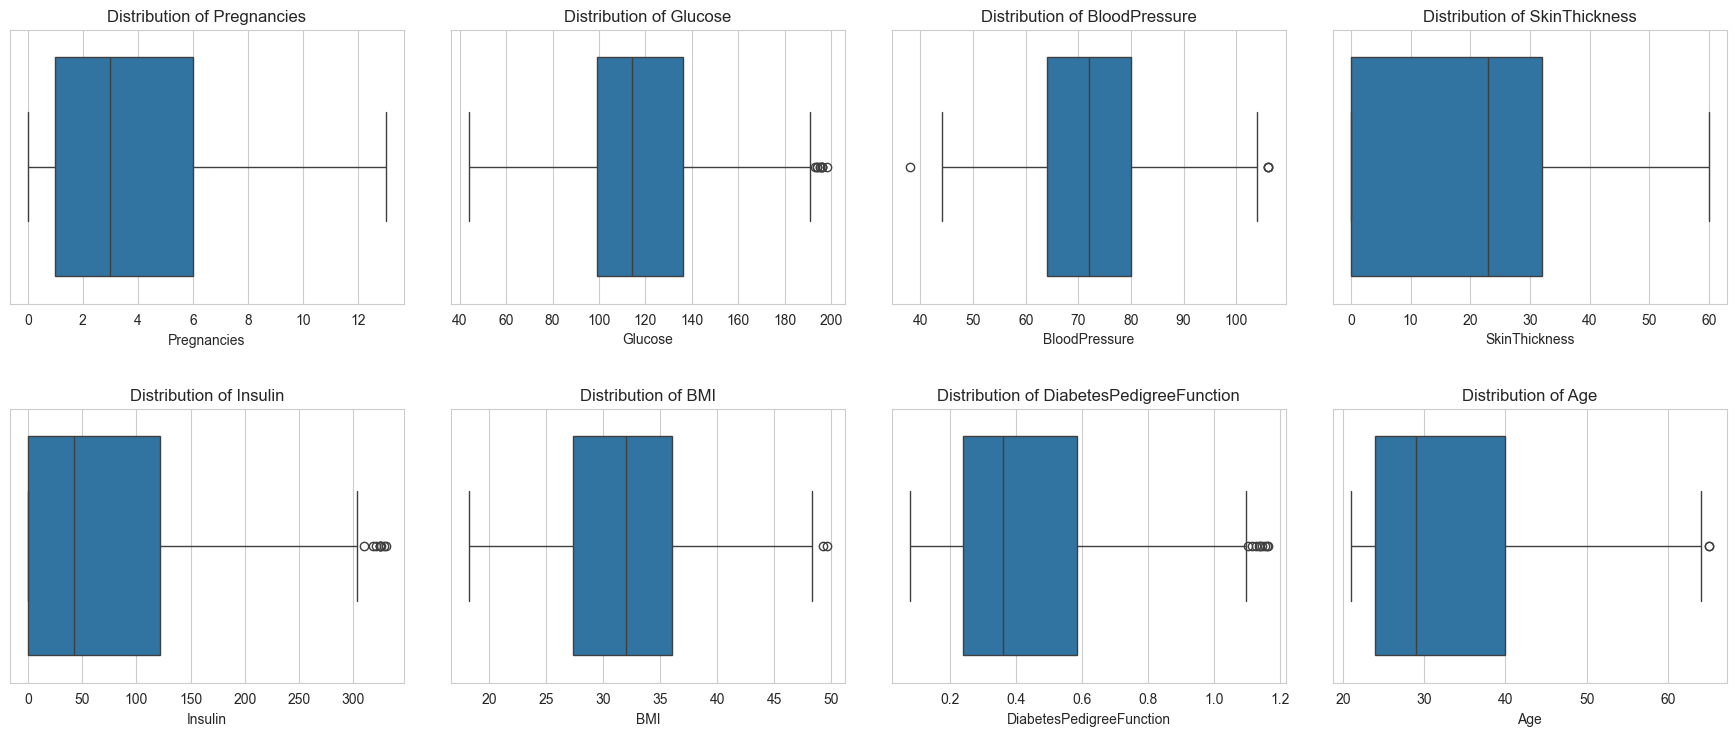

In [281]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create rainbow palette with 8 colors
rainbow_palette = sns.color_palette("rainbow", 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))  # 2 rows, 4 columns

sns.boxplot(data=df, x='Pregnancies', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Pregnancies')

sns.boxplot(data=df, x='Glucose', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Glucose')

sns.boxplot(data=df, x='BloodPressure', ax=axes[0, 2])
axes[0, 2].set_title('Distribution of BloodPressure')

sns.boxplot(data=df, x='SkinThickness', ax=axes[0, 3])
axes[0, 3].set_title('Distribution of SkinThickness')

sns.boxplot(data=df, x='Insulin', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Insulin')

sns.boxplot(data=df, x='BMI', ax=axes[1, 1])
axes[1, 1].set_title('Distribution of BMI')

sns.boxplot(data=df, x='DiabetesPedigreeFunction', ax=axes[1, 2])
axes[1, 2].set_title('Distribution of DiabetesPedigreeFunction')

sns.boxplot(data=df, x='Age', ax=axes[1, 3])
axes[1, 3].set_title('Distribution of Age')

# Improve spacing
plt.tight_layout(pad=3)  # Add padding
plt.show()


In [282]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000,636.000000
mean,3.786164,118.869497,72.007862,20.745283,69.017296,31.964151,0.426237,32.555031,0.309748
std,3.251388,28.996773,11.301102,15.231688,83.601857,6.384132,0.245088,10.879807,0.462754
min,0.000000,44.000000,38.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,0.000000,0.000000,27.300000,0.238750,24.000000,0.000000
50%,3.000000,114.000000,72.000000,23.000000,42.500000,32.000000,0.361000,29.000000,0.000000
75%,6.000000,136.250000,80.000000,32.000000,122.000000,36.000000,0.583000,40.000000,1.000000
max,13.000000,198.000000,106.000000,60.000000,330.000000,49.600000,1.162000,65.000000,1.000000


## Train Test

In [283]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=101)

X_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
160,4,151,90,38,0,29.7,0.294,36
620,2,112,86,42,160,38.4,0.246,28
530,2,122,60,18,106,29.8,0.717,22
682,0,95,64,39,105,44.6,0.366,22
365,5,99,54,28,83,34.0,0.499,30
...,...,...,...,...,...,...,...,...
95,6,144,72,27,228,33.9,0.255,40
727,0,141,84,26,0,32.4,0.433,22
698,4,127,88,11,155,34.5,0.598,28
414,0,138,60,35,167,34.6,0.534,21


## Distance / Gradient Based

## Logistic Regression

In [284]:
#Scaling the data
from sklearn.preprocessing import StandardScaler

ss1 = StandardScaler()

ss1.fit(X_train)

X_train = ss1.transform(X_train)
X_test = ss1.transform(X_test)

In [285]:
from sklearn.linear_model import LogisticRegression

logr1 = LogisticRegression()

logr1.fit(X_train,y_train)

predictedVal1 = logr1.predict(X_test)

predTrain = logr1.predict(X_train)

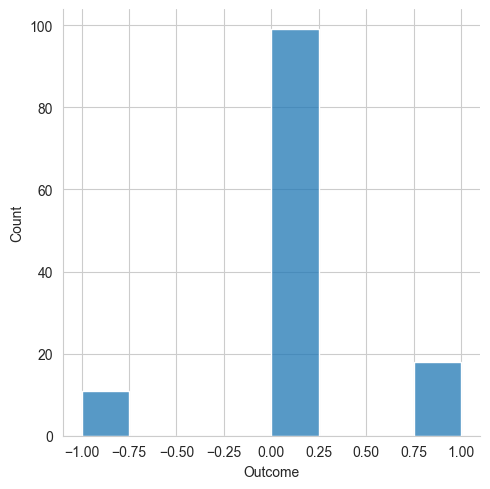

In [286]:
sns.displot(y_test-predictedVal1)

In [287]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('-----------Test Accracy------------')
print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))

print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))


-----------Test Accracy------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        91
           1       0.63      0.51      0.57        37

    accuracy                           0.77       128
   macro avg       0.72      0.70      0.71       128
weighted avg       0.76      0.77      0.77       128

[[80 11]
 [18 19]]
Train Accuracy: 0.7874015748031497
Test Accuracy: 0.7734375


In [288]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=logr1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.7754509803921569
0.06911673202008675


## KNN

In [289]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier()

knn1.fit(X_train,y_train)

predictedVal1 = knn1.predict(X_test)

trainPred = knn1.predict(X_train)

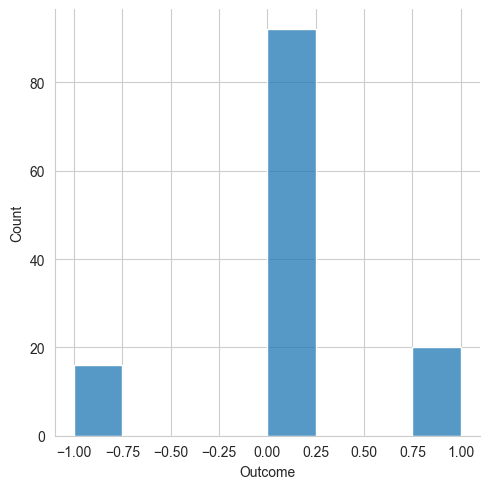

In [290]:
sns.displot(y_test-predictedVal1)

In [291]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('-----------Test Accracy------------')
print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))


print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

-----------Test Accracy------------
              precision    recall  f1-score   support

           0       0.79      0.82      0.81        91
           1       0.52      0.46      0.49        37

    accuracy                           0.72       128
   macro avg       0.65      0.64      0.65       128
weighted avg       0.71      0.72      0.71       128

[[75 16]
 [20 17]]
Train Accuracy: 0.7874015748031497
Test Accuracy: 0.71875


In [292]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=knn1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.756078431372549
0.06863977480383446


## SVC

In [293]:
from sklearn.svm import SVC

svc1 = SVC()

svc1.fit(X_train,y_train)

predictedVal1 = svc1.predict(X_test)

trainPred = svc1.predict(X_train)

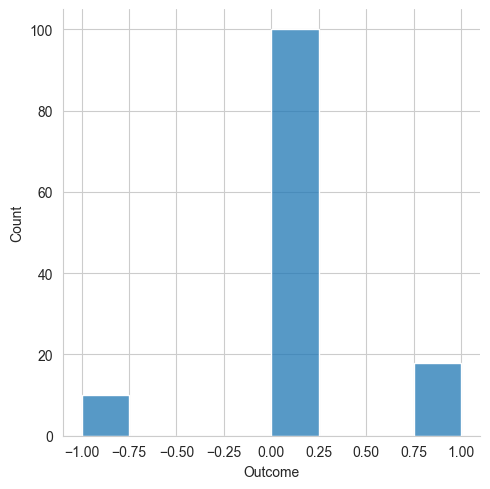

In [294]:
sns.displot(y_test-predictedVal1)

In [295]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('-----------Test Accracy------------')
print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))


print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

-----------Test Accracy------------
              precision    recall  f1-score   support

           0       0.82      0.89      0.85        91
           1       0.66      0.51      0.58        37

    accuracy                           0.78       128
   macro avg       0.74      0.70      0.71       128
weighted avg       0.77      0.78      0.77       128

[[81 10]
 [18 19]]
Train Accuracy: 0.7874015748031497
Test Accuracy: 0.78125


In [296]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=svc1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.7754901960784315
0.042860879352321815


### RBF SVC

In [297]:
from sklearn.svm import SVC

svc2 = SVC(kernel='rbf')

svc2.fit(X_train,y_train)

predictedVal1 = svc2.predict(X_test)

predTrain = svc2.predict(X_train)

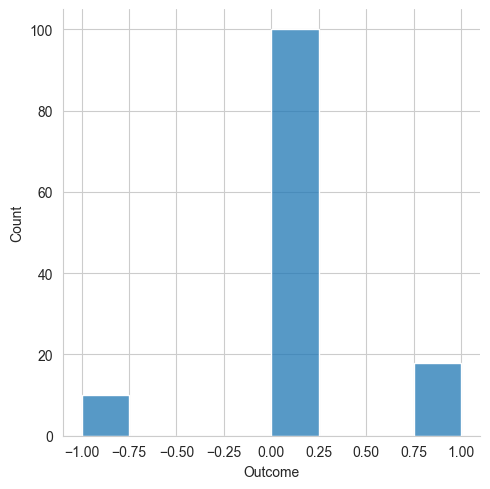

In [298]:
sns.displot(y_test-predictedVal1)

In [299]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('-----------Test Accracy------------')
print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))


print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

-----------Test Accracy------------
              precision    recall  f1-score   support

           0       0.82      0.89      0.85        91
           1       0.66      0.51      0.58        37

    accuracy                           0.78       128
   macro avg       0.74      0.70      0.71       128
weighted avg       0.77      0.78      0.77       128

[[81 10]
 [18 19]]
Train Accuracy: 0.84251968503937
Test Accuracy: 0.78125


In [300]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=svc2, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.7754901960784315
0.042860879352321815


## Probabilty based / Trees

In [301]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Outcome')
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=101)

## Naive Bayes

In [302]:
from sklearn.naive_bayes import GaussianNB

nb1 = GaussianNB()

nb1.fit(X_train,y_train)

predictedVal1 = nb1.predict(X_test)

trainPred = nb1.predict(X_train)

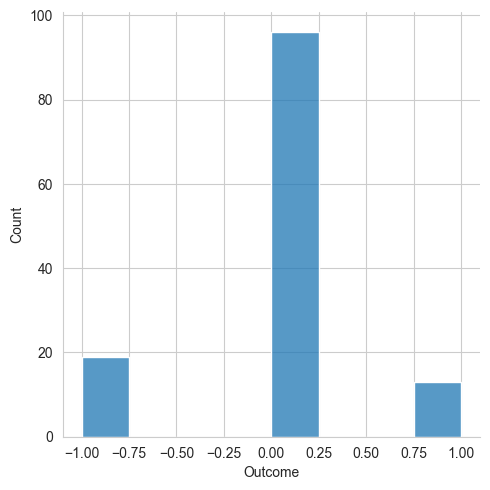

In [303]:
sns.displot(y_test-predictedVal1)

In [304]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('-----------Train Accracy------------')
print(classification_report(y_train,predTrain))
print(confusion_matrix(y_test,predictedVal1))


print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

-----------Train Accracy------------
              precision    recall  f1-score   support

           0       0.83      0.96      0.89       348
           1       0.88      0.58      0.70       160

    accuracy                           0.84       508
   macro avg       0.86      0.77      0.80       508
weighted avg       0.85      0.84      0.83       508

[[72 19]
 [13 24]]
Train Accuracy: 0.84251968503937
Test Accuracy: 0.75


In [305]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=nb1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.7618039215686274
0.06763340584019127


## Decision Tree

In [306]:
from sklearn.tree import DecisionTreeClassifier

dtc1 = DecisionTreeClassifier()

dtc1.fit(X_train,y_train)

predictedVal1 = dtc1.predict(X_test)

trainPred = dtc1.predict(X_train)

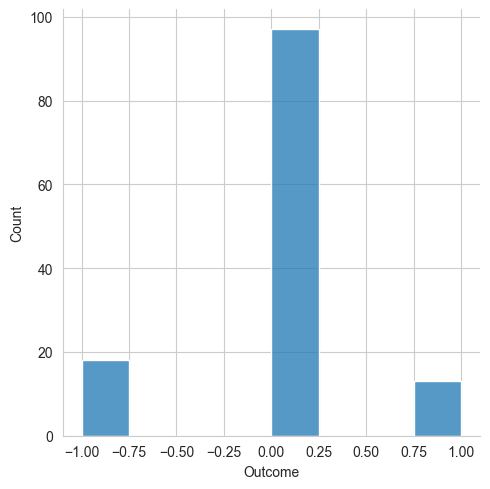

In [307]:
sns.displot(y_test-predictedVal1)

In [308]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print('-----------Test Accuracy------------')
print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))

print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

-----------Test Accuracy------------
              precision    recall  f1-score   support

           0       0.85      0.80      0.82        91
           1       0.57      0.65      0.61        37

    accuracy                           0.76       128
   macro avg       0.71      0.73      0.72       128
weighted avg       0.77      0.76      0.76       128

[[73 18]
 [13 24]]
Train Accuracy: 0.84251968503937
Test Accuracy: 0.7578125


In [309]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=dtc1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.7420392156862745
0.05338025617517381


## Random Forest

In [310]:
from sklearn.ensemble import RandomForestClassifier

rfc1 = RandomForestClassifier()

rfc1.fit(X_train,y_train)

predictedVal1 = rfc1.predict(X_test)
trainVal1 = rfc1.predict(X_train)


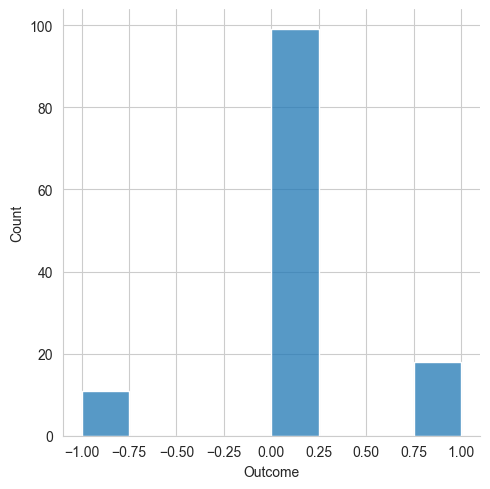

In [311]:
sns.displot(y_test-predictedVal1)

In [312]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))

print('Train Accuracy:',accuracy_score(y_train,trainVal1))
print('Train Accuracy:',accuracy_score(y_test,predictedVal1))


              precision    recall  f1-score   support

           0       0.82      0.88      0.85        91
           1       0.63      0.51      0.57        37

    accuracy                           0.77       128
   macro avg       0.72      0.70      0.71       128
weighted avg       0.76      0.77      0.77       128

[[80 11]
 [18 19]]
Train Accuracy: 1.0
Train Accuracy: 0.7734375


In [313]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=rfc1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print('-----------Cross Val Score------------')
print(cvs1.mean())
print(cvs1.std())

-----------Cross Val Score------------
0.8089803921568628
0.03865419597650136


## XGBoost


In [314]:
from xgboost import XGBClassifier

xg1 = XGBClassifier()

xg1.fit(X_train, y_train)

predictedVal1 = xg1.predict(X_test)

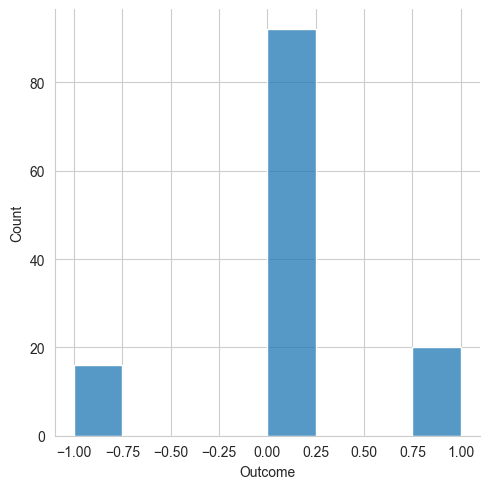

In [315]:
sns.displot(y_test-predictedVal1)

In [316]:
# Classification report and confusion matrix

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,predictedVal1))
print(confusion_matrix(y_test,predictedVal1))

print('Train Accuracy:',accuracy_score(y_train,predTrain))
print('Test Accuracy:',accuracy_score(y_test,predictedVal1))

              precision    recall  f1-score   support

           0       0.79      0.82      0.81        91
           1       0.52      0.46      0.49        37

    accuracy                           0.72       128
   macro avg       0.65      0.64      0.65       128
weighted avg       0.71      0.72      0.71       128

[[75 16]
 [20 17]]
Train Accuracy: 0.84251968503937
Test Accuracy: 0.71875


In [317]:
## Advanced perfomance evalutaion
from sklearn.model_selection import cross_val_score

cvs1 = cross_val_score(estimator=xg1, X=X_train, y=y_train, cv=10, n_jobs=-1)

print(cvs1.mean())
print(cvs1.std())

0.7774901960784313
0.03678096895199051


## Using GridCV

In [318]:
from sklearn.model_selection import GridSearchCV

#Random forest
parameters = {
    'n_estimators': [100],
    'max_depth': [3, 4],     
}

gs1 = GridSearchCV(estimator=rfc1, param_grid=parameters, scoring= 'accuracy', cv= 10, n_jobs=-1)

gs1.fit(X_train,y_train)
print("Best parameters:", gs1.best_params_)
print("Best cross-validation score:", gs1.best_score_)


Best parameters: {'max_depth': 4, 'n_estimators': 100}
Best cross-validation score: 0.7912549019607844


In [319]:
from sklearn.metrics import accuracy_score

# Predict on train and test
y_train_pred = gs1.best_estimator_.predict(X_train)
y_test_pred = gs1.best_estimator_.predict(X_test)

# Accuracy on both
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.844488188976378
Test Accuracy: 0.7578125


In [320]:
#XGBClassifier

parameters = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [2, 3],
}

gs1 = GridSearchCV(estimator=xg1, param_grid=parameters, scoring= 'accuracy', cv= 10, n_jobs=-1)

gs1.fit(X_train,y_train)
print("Best parameters:", gs1.best_params_)
print("Best cross-validation score:", gs1.best_score_)


Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best cross-validation score: 0.8050588235294118


In [321]:
from sklearn.metrics import accuracy_score

y_train_pred = gs1.best_estimator_.predict(X_train)
y_test_pred = gs1.best_estimator_.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.8385826771653543
Test Accuracy: 0.7734375


## Making a Single Prediction

In [322]:
print('1st Prediciton: ',gs1.predict([[0, 120, 60, 18, 106, 25, 0.717, 23]]))

print('2nd Prediciton: ',gs1.predict([[0, 140, 60, 18, 106, 30, 0.717, 40]]))

#  The model predicts that the first patient is not diabetic (0), while the second patient is diabetic (1), 
#  likely due to higher glucose and age values.

1st Prediciton:  [0]
2nd Prediciton:  [1]
